In [138]:
#Importing Pandas
import pandas as pd

from scipy.stats import pointbiserialr


#Opening the csv file
df = pd.read_csv("team17_callcenter_modified.csv")


r, p_value = pointbiserialr(df['resolved'], df['duration_minutes'])
print("Correlation:", r)
print("P-value:", p_value)

#shape or sum like that calm shi
df.shape # rows, columns

df['date'] = pd.to_datetime(df['date'])
df.info()

Correlation: 0.010085680710478946
P-value: 0.7382796766213664
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   call_id                1100 non-null   int64         
 1   date                   1100 non-null   datetime64[ns]
 2   agent_id               1100 non-null   int64         
 3   call_type              1100 non-null   object        
 4   duration_minutes       1100 non-null   int64         
 5   wait_time_minutes      1055 non-null   float64       
 6   resolved               1100 non-null   bool          
 7   customer_satisfaction  1046 non-null   float64       
 8   time_of_day            1100 non-null   object        
 9   priority               1100 non-null   object        
dtypes: bool(1), datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 78.5+ KB


1. What is the resolution rate by call type?

   Call Type  Resolution Rate
0  Complaint        77.500000
1    Inquiry        74.725275
2      Sales        75.280899
3    Support        71.776156


<AxesSubplot: title={'center': 'Resolution Percentage by call type'}, xlabel='Call Type', ylabel='Resolution Percentage'>

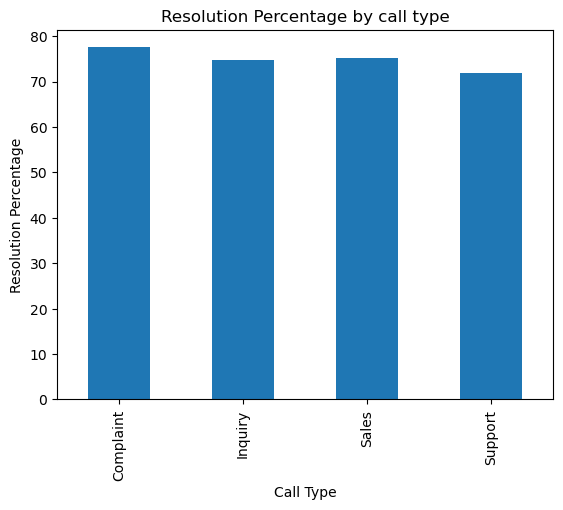

In [139]:
#Grouping  call types together, and then finding the resolution rate by call type
test = df.groupby('call_type')['resolved'].mean()* 100

new = test.reset_index().rename(columns={'call_type':'Call Type', 'resolved':'Resolution Rate'})
#Printing the information
print(new)

#Plotting the information into a bar graph
test.plot(kind="bar", ylabel = 'Resolution Percentage', xlabel = 'Call Type', title = 'Resolution Percentage by call type')

2. How does wait time affect customer satisfaction?

   Satisfaction  Wait Time Avg
0           1.0       2.384615
1           2.0       2.677966
2           3.0       2.959799
3           4.0       2.576705
4           5.0       2.551601


<AxesSubplot: title={'center': 'Average Wait Time Per Customer Satisfaction'}, xlabel='Customer Satisfaction', ylabel='Avg Wait Time'>

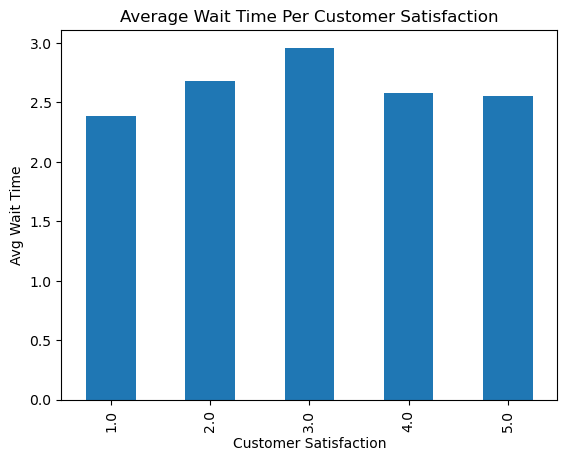

In [140]:
#Grouping by customer satisfaction
test = df.groupby('customer_satisfaction')['wait_time_minutes'].mean()

#Printing the information
new = test.reset_index().rename(columns={'customer_satisfaction':'Satisfaction', 'wait_time_minutes':'Wait Time Avg'})
print(new)

#Plotting the information into a bar graph
test.plot(kind='bar', xlabel='Customer Satisfaction', ylabel='Avg Wait Time', title='Average Wait Time Per Customer Satisfaction')

3. Which time of day has the longest average call duration?

In [141]:
#Grouping time of day vs duration of call
test = df.groupby('time_of_day')['duration_minutes'].mean()

#Printing the information
new = test.reset_index().rename(columns={'time_of_day':'Time Of Day', 'duration_minutes':'Duration'})
print(new)

  Time Of Day   Duration
0   Afternoon   9.247881
1     Evening   9.012295
2     Morning  10.283854


4. What percentage of high-priority calls are resolved?

In [142]:
#Grouping priority vs resolved percentage
df.groupby('priority')['resolved'].value_counts(normalize=True)*100

priority  resolved
High      True        69.590643
          False       30.409357
Low       True        71.647510
          False       28.352490
Medium    True        79.852580
          False       20.147420
Name: proportion, dtype: float64

5. How does agent workload (calls per agent) vary by time of day?

  Time Of Day          0
0   Afternoon  12.102564
1     Evening   6.256410
2     Morning   9.846154


<AxesSubplot: title={'center': 'Number of Calls Per Agent Each Time of Day'}>

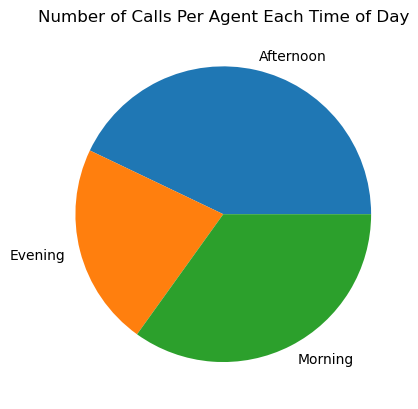

In [143]:
#Grouping time of day with number of calls
test = df.groupby(['time_of_day', 'agent_id']).size().groupby('time_of_day').mean()

#Printing the information
new = test.reset_index().rename(columns={'time_of_day':'Time Of Day'})
print(new)

#Graping pie plot
test.plot(kind='pie', title='Number of Calls Per Agent Each Time of Day')

Question 6: Is there a correlation between call duration and resolution?

In [144]:
#Percent resolved vs how long the call is
test = df.groupby('resolved')['duration_minutes'].mean()

#Printing the information
new = test.reset_index().rename(columns={'resolved':'Resolved', 'duration_minutes':'Duration'})
print(new)

   Resolved  Duration
0     False  9.439716
1      True  9.597800


    Duration  Resolution Rate  Call Count
0          1        72.131148          61
1          2        68.253968          63
2          3        76.136364          88
3          4        70.512821          78
4          5        77.108434          83
5          6        77.142857          70
6          7        70.000000          70
7          8        75.757576          66
8          9        77.049180          61
9         10        82.258065          62
10        11        71.428571          42
11        12        73.584906          53
12        13        70.270270          37
13        14        73.333333          30
14        15        71.052632          38
15        16        73.529412          34
16        17        77.272727          22
17        18        85.714286          21
18        19        77.777778          18
19        20        80.952381          21
20        21        70.588235          17
21        22        66.666667           6
22        23        63.636364     

<AxesSubplot: title={'center': 'Resolution Rate For Each Call Duration'}, xlabel='Call Duration', ylabel='Resolution Rate'>

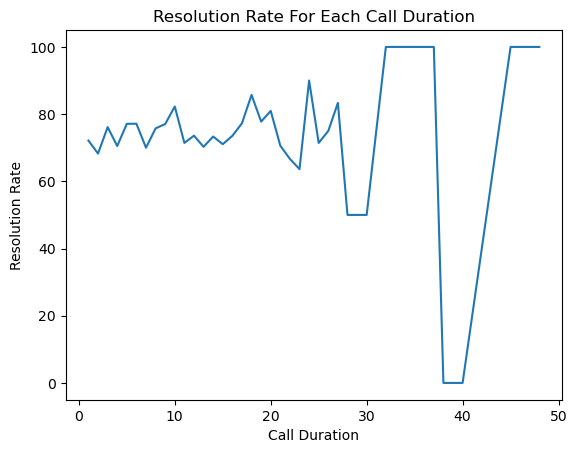

In [145]:
#How long is each call vs resolution rate
test = df.groupby('duration_minutes')['resolved'].mean().mul(100)

other = df.groupby('duration_minutes')['resolved'].size()

#Printing the information
new = (
    pd.concat([test, other], axis=1)
      .reset_index()
      .rename(columns={
          'duration_minutes': 'Duration',
          'resolved': 'Resolution Rate',
      })
)
new.columns.values[2] = 'Call Count'

print(new)


#Plotting the graph
test.plot(
    title='Resolution Rate For Each Call Duration',
    xlabel='Call Duration', 
    ylabel='Resolution Rate',
         )